In [1]:
import numpy as np
import tensorflow as tf
from src import hnn
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.set_visible_devices(gpus[2], "GPU")

2025-02-02 16:27:06.143621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738484826.164072 2020525 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738484826.170543 2020525 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-02 16:27:06.193516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
def training_test(config):
    if "type_NN" not in config.keys() or config["type_NN"] == "HNN":
        model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
    elif config["type_NN"] == "PMHNN":
        model = hnn.PMHNN(config["inputdim_NN"], config["num_hidden"], config["num_layers"], acti=config["acti"], dim_marginal=0, coef=np.array([[0]]*(config["input_dim"]//2)), obs=np.array([[0]]*(config["input_dim"]//2)))
    else:
        raise ValueError(f"Invalid 'type_NN' value: {config.get('type_NN', None)}")
    
    data = tf.random.normal(shape=(config["num_samples"], config["input_dim"]), dtype=tf.float32)
    grad = tf.concat([data[:, len(data[0]//2):], -data[:,:len(data[0]//2)]], axis=-1)

    loss_obj = tf.keras.losses.MeanSquaredError()
    optimizer = tf.keras.optimizers.Adam()
    
    @tf.function
    def train_step(x,y):
        with tf.GradientTape() as tape:
            y_pred = model.get_gradient(x)
            loss = loss_obj(y,y_pred)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    losses, bestmodel = [], None
    for idx_epoch in range(config["train_epoch"]):
        print(f"Begin the {idx_epoch}th training epoch:")
        for idx_step in range(config["train_step"]):
            train_step(data, grad)
        
        train_timegrads_hat = model.get_gradient(data)
        train_dist = (grad - train_timegrads_hat)**2
        losses.append(tf.reduce_mean(train_dist).numpy())
        # if tf.reduce_mean(train_dist).numpy() < bestloss:
        #     bestloss = tf.reduce_mean(train_dist).numpy()
        print('Train loss {:.4e} +/- {:.4e}'
            .format(tf.reduce_mean(train_dist).numpy(), tf.math.reduce_std(train_dist).numpy()/np.sqrt(train_dist.shape[0])))
    return np.array(losses)
    


In [6]:
config = {
        "pseudo-marginal" : True,
        "type_NN" : "HNN",
        "input_dim": 25000,
        "num_hidden": 500,
        "num_layers": 3,
        "output_dim": 25000,
        "acti" : "sin",
        "baseline" : False,
        "field_type" : "solenoidal",
        "separate_fields" : False,
        "train_epoch" : 100,
        "train_step" : 100,
        "num_samples" : 16,
    }

In [8]:
hnnloss = {}
for dim in [1000, 10000, 25000, 50000, 100000]:
    config["baseline"] = False
    config["input_dim"] = dim
    config["output_dim"] = dim
    hnnloss[dim] = training_test(config)

fnnloss = {}
for dim in [1000, 10000, 25000, 50000, 100000]:
    config["baseline"] = True
    config["input_dim"] = dim
    config["output_dim"] = dim
    fnnloss[dim] = training_test(config)


Begin the 0th training epoch:
Train loss 2.3065e-05 +/- 8.3143e-06
Begin the 1th training epoch:
Train loss 1.1237e-06 +/- 4.3780e-07
Begin the 2th training epoch:
Train loss 4.3042e-03 +/- 1.5228e-03
Begin the 3th training epoch:
Train loss 9.9873e-05 +/- 3.5821e-05
Begin the 4th training epoch:
Train loss 5.7490e-08 +/- 2.0897e-08
Begin the 5th training epoch:
Train loss 1.7814e-05 +/- 6.7664e-06
Begin the 6th training epoch:
Train loss 1.5150e-09 +/- 5.4674e-10
Begin the 7th training epoch:
Train loss 2.1614e-05 +/- 7.6815e-06
Begin the 8th training epoch:
Train loss 7.5658e-10 +/- 2.8332e-10
Begin the 9th training epoch:
Train loss 6.4754e-05 +/- 2.4458e-05
Begin the 10th training epoch:
Train loss 7.9647e-07 +/- 2.8269e-07
Begin the 11th training epoch:
Train loss 1.0090e-10 +/- 3.5792e-11
Begin the 12th training epoch:
Train loss 9.3443e-06 +/- 3.4681e-06
Begin the 13th training epoch:
Train loss 4.1953e-10 +/- 1.4922e-10
Begin the 14th training epoch:
Train loss 2.1867e-03 +/- 7

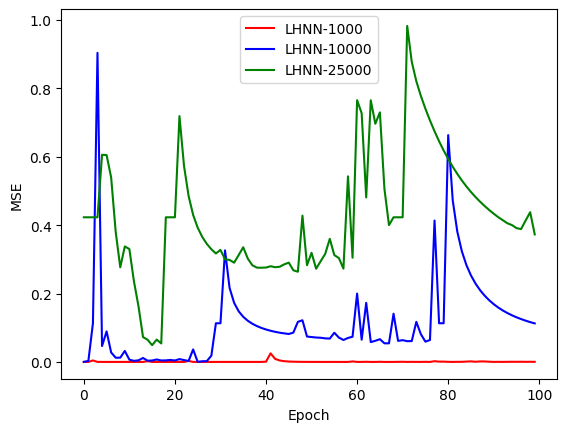

In [21]:
import matplotlib.pyplot as plt

def removeoci(a):
    a = a.copy()
    a[a>1] = a[a<1].mean()
    return a

for dim, color in zip([1000, 10000, 25000], ["red", "blue", "green", "orange"]):
    plt.plot(removeoci(hnnloss[dim]), label=f"LHNN-{dim}", linestyle="-", color=color)
    # plt.plot(removeoci(fnnloss[dim]), label=f"FNN-{dim}", linestyle="--", color=color)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()